In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mode
from matplotlib.ticker import MaxNLocator
import numpy as np
import altair as alt

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.shape

(768, 9)

In [9]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [10]:
results = {}

# List of all attributes to process (excluding 'Outcome')
attributes = df.columns.tolist()
if 'Outcome' in attributes:
    attributes.remove('Outcome')

# Calculate statistics for each attribute
for col in attributes:
    # Mean
    col_mean = df[col].mean()

    # Median (50th percentile)
    col_median = df[col].median()

    # Mode (handling potential multiple modes by taking the first one)
    try:
        # Use keepdims=True for compatibility with newer SciPy versions
        col_mode = mode(df[col], keepdims=True).mode[0]
    except AttributeError:
        # Fallback for older scipy versions
        col_mode = df[col].mode().iloc[0]

    # Quartiles (25th and 75th)
    # Note: Quartiles include the median (0.50), but we already calculated it separately.
    col_quartiles = df[col].quantile([0.25, 0.75]).to_dict()

    # Store the results
    results[col] = {
        'Mean': col_mean,
        'Median': col_median,
        'Mode': col_mode,
        '25th Percentile (Q1)': col_quartiles[0.25],
        '75th Percentile (Q3)': col_quartiles[0.75]
    }

In [11]:
stats_df = pd.DataFrame.from_dict(results, orient='index')
stats_df.index.name = 'Attribute'
print(stats_df.to_markdown(numalign="left", stralign="left", floatfmt=".3f"))

| Attribute                | Mean    | Median   | Mode   | 25th Percentile (Q1)   | 75th Percentile (Q3)   |
|:-------------------------|:--------|:---------|:-------|:-----------------------|:-----------------------|
| Pregnancies              | 3.845   | 3.000    | 1.000  | 1.000                  | 6.000                  |
| Glucose                  | 120.895 | 117.000  | 99.000 | 99.000                 | 140.250                |
| BloodPressure            | 69.105  | 72.000   | 70.000 | 62.000                 | 80.000                 |
| SkinThickness            | 20.536  | 23.000   | 0.000  | 0.000                  | 32.000                 |
| Insulin                  | 79.799  | 30.500   | 0.000  | 0.000                  | 127.250                |
| BMI                      | 31.993  | 32.000   | 32.000 | 27.300                 | 36.600                 |
| DiabetesPedigreeFunction | 0.472   | 0.372    | 0.254  | 0.244                  | 0.626                  |
| Age              

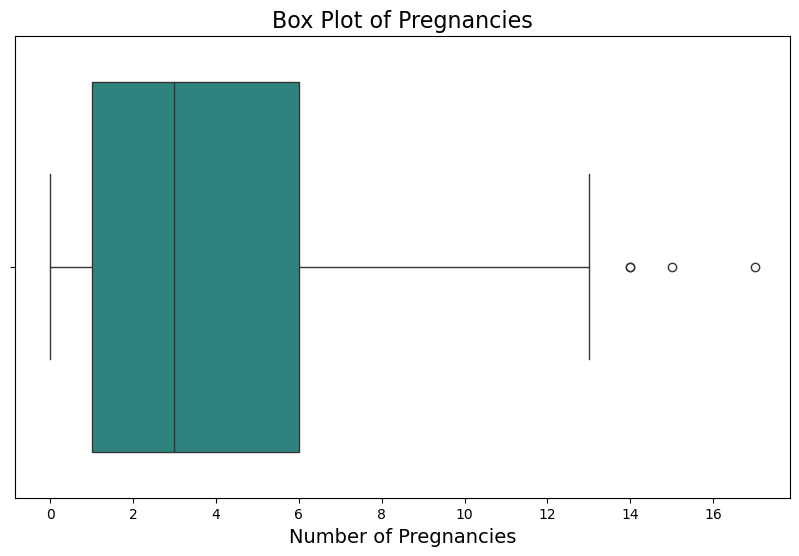

In [12]:
color = sns.color_palette("viridis", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Pregnancies'], color=color)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Box Plot of Pregnancies', fontsize=16)
plt.xlabel('Number of Pregnancies', fontsize=14)
plt.show()

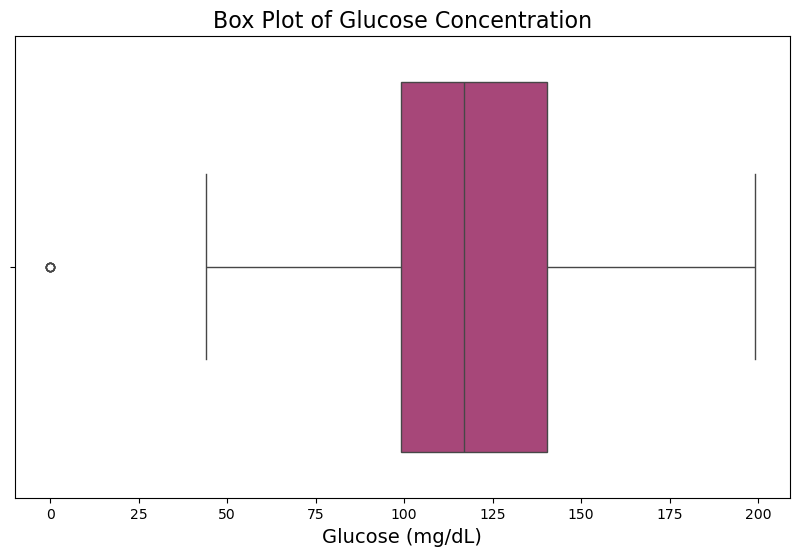

In [13]:
color = sns.color_palette("magma", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Glucose'], color=color)
plt.title('Box Plot of Glucose Concentration', fontsize=16)
plt.xlabel('Glucose (mg/dL)', fontsize=14)
plt.show()

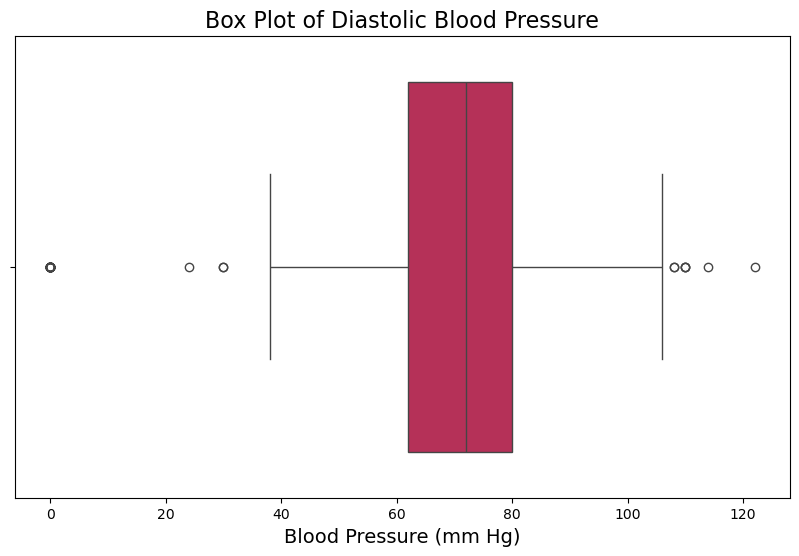

In [14]:
color = sns.color_palette("rocket", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['BloodPressure'], color=color)
plt.title('Box Plot of Diastolic Blood Pressure', fontsize=16)
plt.xlabel('Blood Pressure (mm Hg)', fontsize=14)
plt.show()

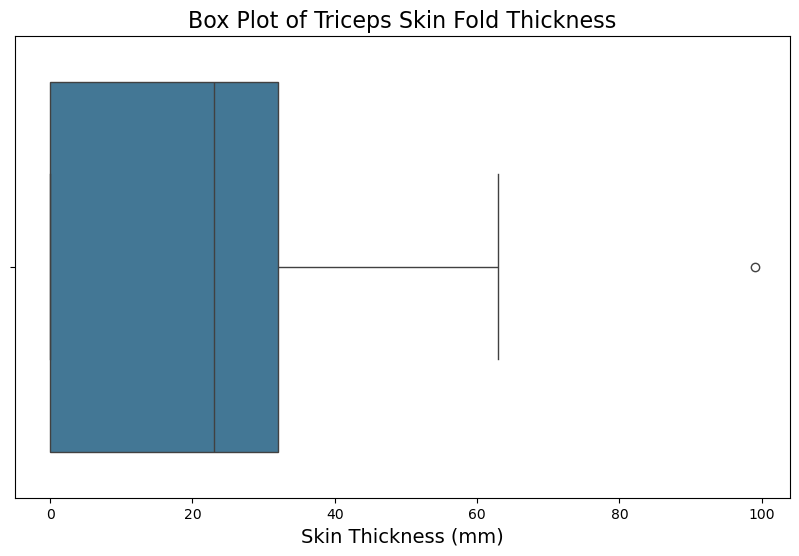

In [15]:
color = sns.color_palette("mako", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['SkinThickness'], color=color)
plt.title('Box Plot of Triceps Skin Fold Thickness', fontsize=16)
plt.xlabel('Skin Thickness (mm)', fontsize=14)
plt.show()

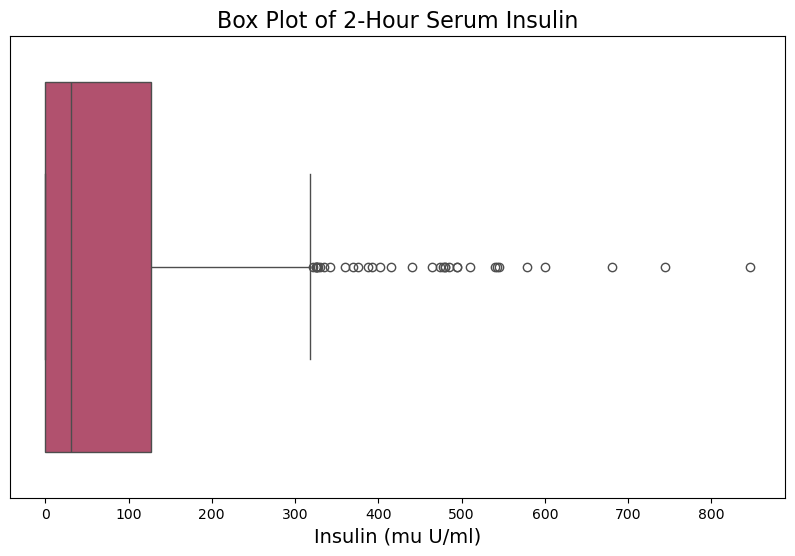

In [16]:
color = sns.color_palette("flare", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Insulin'], color=color)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Box Plot of 2-Hour Serum Insulin', fontsize=16)
plt.xlabel('Insulin (mu U/ml)', fontsize=14)
plt.yticks([])
plt.show()

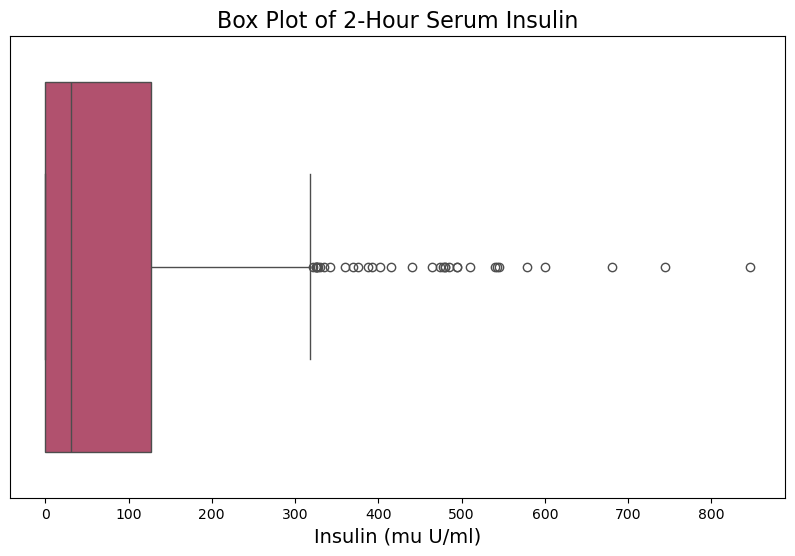

In [17]:
color = sns.color_palette("flare", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Insulin'], color=color)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Box Plot of 2-Hour Serum Insulin', fontsize=16)
plt.xlabel('Insulin (mu U/ml)', fontsize=14)
plt.yticks([])
plt.show()

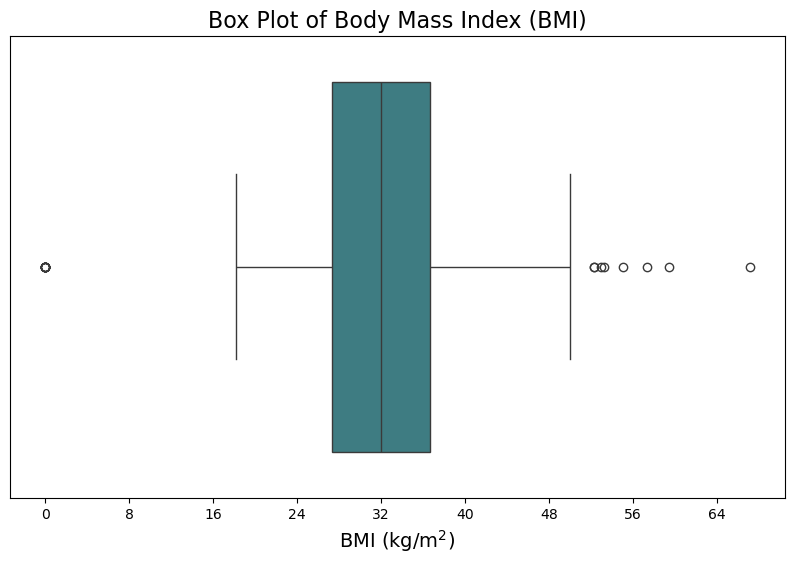

In [18]:
color = sns.color_palette("crest", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['BMI'], color=color)
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=10))
plt.title('Box Plot of Body Mass Index (BMI)', fontsize=16)
plt.xlabel('BMI ($\mathrm{kg/m}^2$)', fontsize=14)
plt.yticks([])

plt.show()

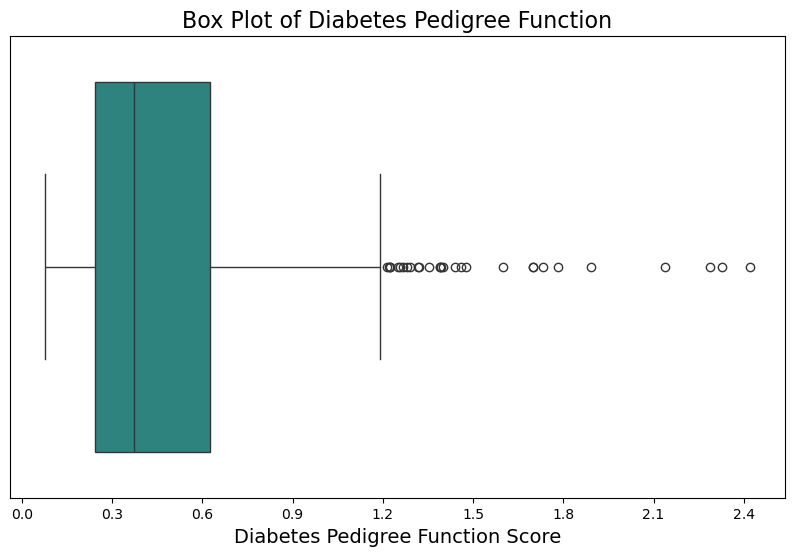

In [19]:
color = sns.color_palette("viridis", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['DiabetesPedigreeFunction'], color=color)
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=10))
plt.title('Box Plot of Diabetes Pedigree Function', fontsize=16)
plt.xlabel('Diabetes Pedigree Function Score', fontsize=14)
plt.yticks([])
plt.show()

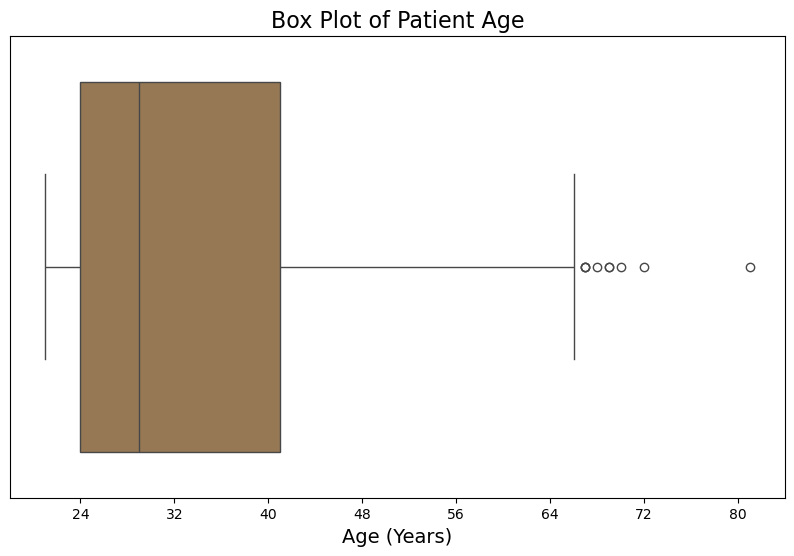

In [20]:
color = sns.color_palette("cubehelix", 1)[0]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Age'], color=color)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Box Plot of Patient Age', fontsize=16)
plt.xlabel('Age (Years)', fontsize=14)
plt.yticks([])
plt.show()

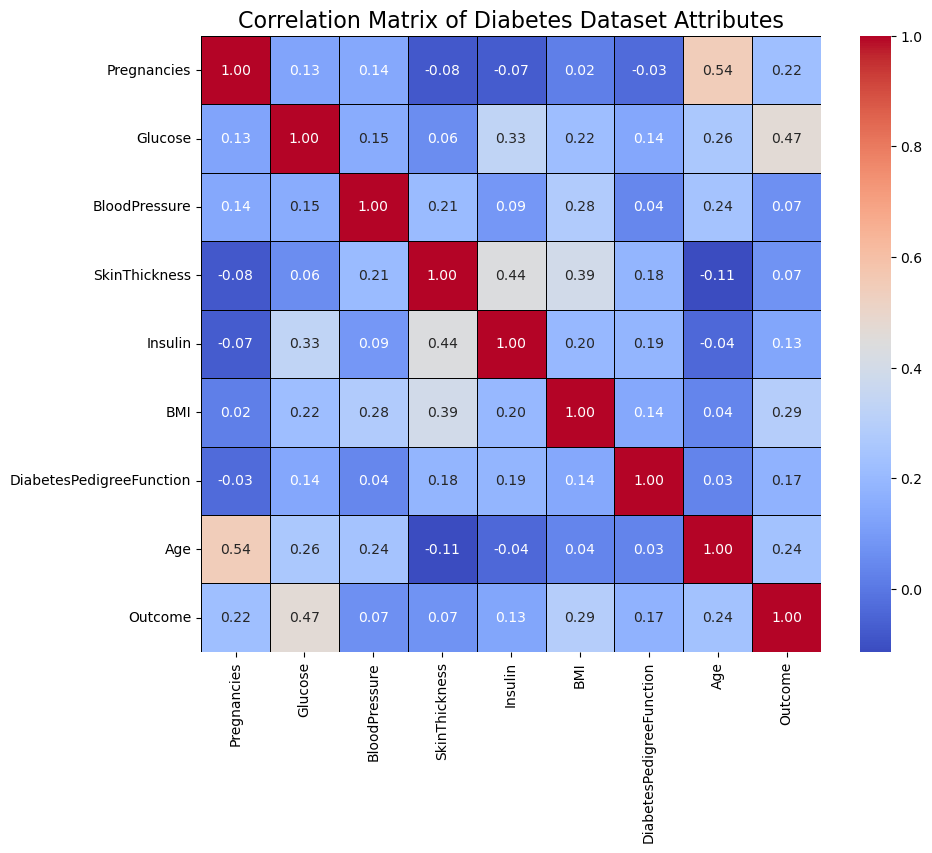


Correlation with Outcome (Diabetes Diagnosis):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [21]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,          
    fmt=".2f",           # Format the annotation to 2 decimal places
    cmap='coolwarm',     # Use a distinct color map (e.g., 'coolwarm')
    cbar=True,           # Show the color bar
    linewidths=0.5,      # Add lines between squares
    linecolor='black'    # Set the line color
)
plt.title('Correlation Matrix of Diabetes Dataset Attributes', fontsize=16)
plt.show()
print("\nCorrelation with Outcome (Diabetes Diagnosis):")
print(correlation_matrix['Outcome'].sort_values(ascending=False))

C:\Users\manoj\AppData\Local\Temp\ipykernel_15880\3864000543.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\manoj\AppData\Local\Temp\ipykernel_15880\3864000543.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\manoj\AppData\Local\Temp\ipykernel_15880\3864000543.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\manoj\AppData\Local\Temp\ipykernel_15880\3864000543.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

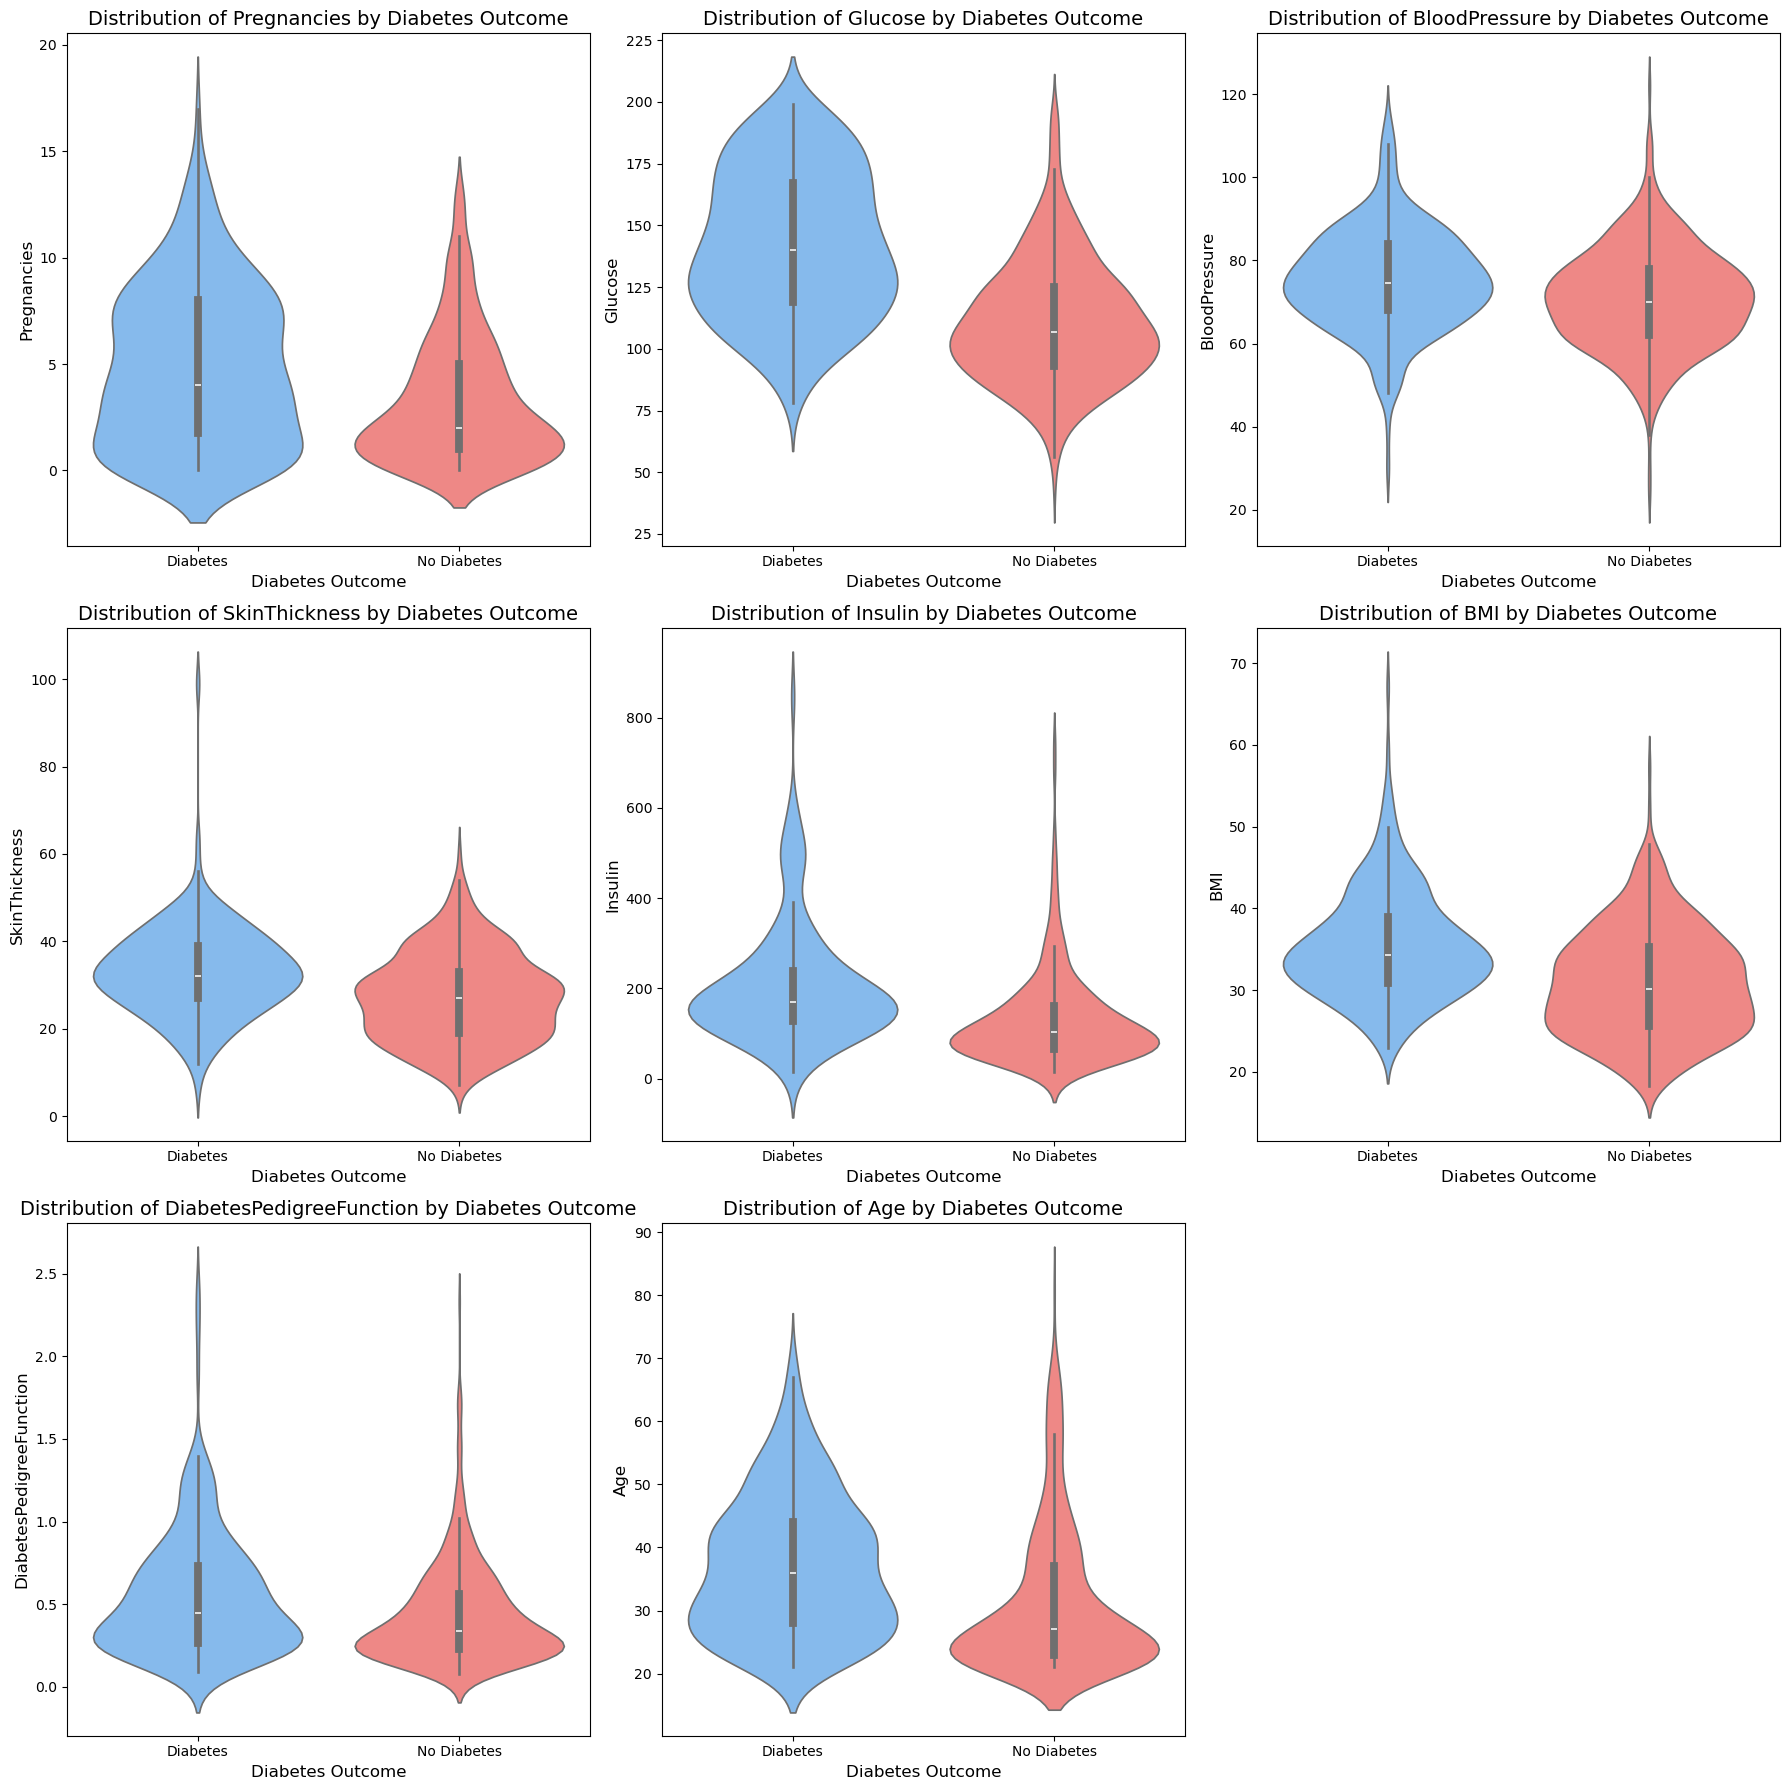

In [22]:
cols_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Create a copy and replace 0s with NaN for accurate distribution plotting
# This step is CRUCIAL to prevent the biologically impossible zero values from skewing the violin plots.
df_clean = df.copy()
df_clean[cols_to_clean] = df_clean[cols_to_clean].replace(0, np.nan)

# List of all predictor attributes (excluding the target 'Outcome')
predictor_attributes = [col for col in df_clean.columns if col != 'Outcome']

# Melt the dataframe to long format for easier plotting with seaborn
df_melted = df_clean.melt(id_vars='Outcome', value_vars=predictor_attributes,
                          var_name='Attribute', value_name='Value')

# Map Outcome to readable labels for the plot
df_melted['Outcome_Label'] = df_melted['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})

# Set up the subplot grid (3 rows, 3 columns for 8 attributes + 1 empty slot)
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 18))
axes = axes.flatten()

# Iterate through attributes and create violin plots on the grid
for i, col in enumerate(predictor_attributes):
    # Filter the melted data for the current attribute
    data_to_plot = df_melted[df_melted['Attribute'] == col]

    # Create the violin plot
    sns.violinplot(
        x='Outcome_Label',
        y='Value',
        data=data_to_plot,
        ax=axes[i],
        palette=['#75bbfd', '#ff7875']  # Custom colors (Blue for No Diabetes, Red for Diabetes)
    )

    # Set titles and labels
    axes[i].set_title(f'Distribution of {col} by Diabetes Outcome', fontsize=14)
    axes[i].set_xlabel('Diabetes Outcome', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

# Remove the unused subplot (the 9th one, index 8)
if len(predictor_attributes) < len(axes):
    fig.delaxes(axes[len(predictor_attributes)])

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# To display the plot instead of saving it, you would use plt.show()
# plt.savefig('violin_plots_by_outcome.png')

plt.show()

## Detect and treat outliers

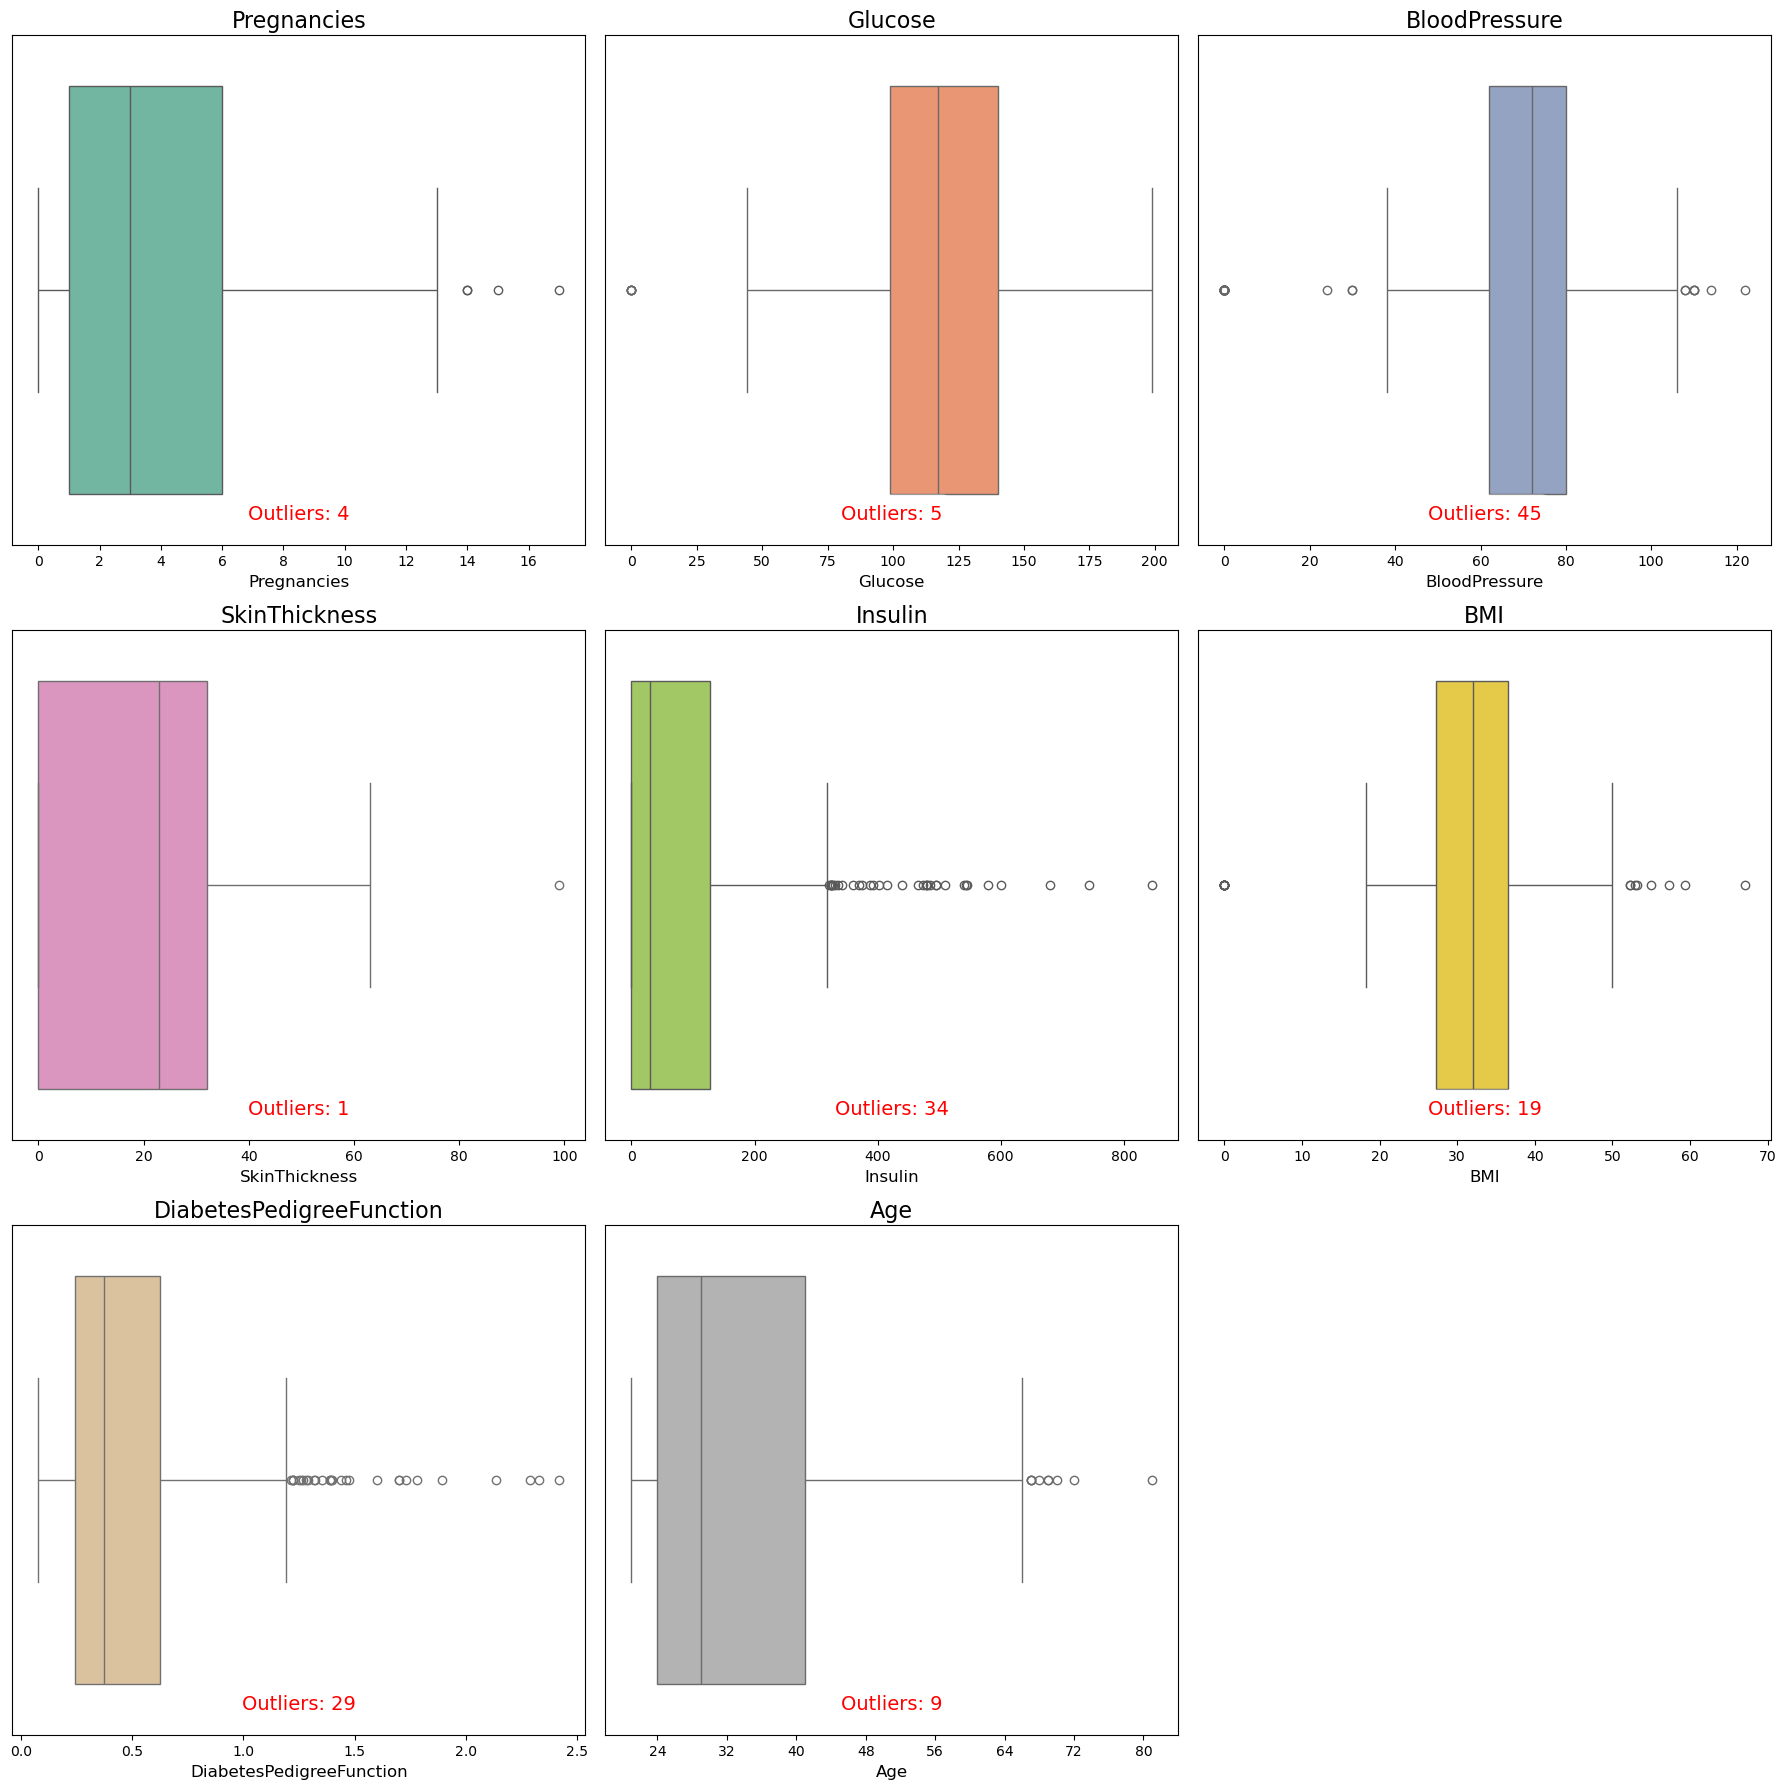

In [23]:
predictor_attributes = [col for col in df.columns if col != 'Outcome']

# Set up the subplot grid
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 18))
axes = axes.flatten()

# Iterate through attributes and create box plots
for i, col in enumerate(predictor_attributes):
    # Calculate IQR and bounds for outlier detection (1.5 * IQR)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    low_outliers = df[df[col] < lower_bound].shape[0]
    high_outliers = df[df[col] > upper_bound].shape[0]
    total_outliers = low_outliers + high_outliers

    # Create the box plot on the current axis
    # Using a different color for each plot in the Set2 palette
    sns.boxplot(x=df[col], ax=axes[i], color=sns.color_palette("Set2")[i % 8])

    # Set the title
    axes[i].set_title(f'{col}', fontsize=16)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_yticks([]) # Remove y-axis ticks

    # Add annotation for outlier count
    # Position the text slightly below the plot area
    axes[i].text(
        0.5, 0.05,
        f'Outliers: {total_outliers}',
        transform=axes[i].transAxes,
        ha='center',
        fontsize=14,
        color='red',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5')
    )

    # Ensure only integer ticks for appropriate columns
    if col in ['Pregnancies', 'Age']:
        axes[i].xaxis.set_major_locator(MaxNLocator(integer=True))

# Remove the unused subplot (the 9th one, index 8)
if len(predictor_attributes) < len(axes):
    fig.delaxes(axes[len(predictor_attributes)])

# Adjust layout
plt.tight_layout()

# To display the plot instead of saving it, you would use plt.show()
# plt.savefig('outlier_visualization_boxplots.png')

plt.show()

### To deal with Outlier we need Domain knowladge

#### (1) Pregnancies

In [24]:
attribute = 'Pregnancies'

# 1. Calculate Quartiles and IQR
Q1 = df[attribute].quantile(0.25)
Q3 = df[attribute].quantile(0.75)
IQR = Q3 - Q1

# 2. Calculate Outlier Fences (Lower and Upper Bounds)
# Using 1.5 * IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Detect Outliers
# Identify rows where the value is an outlier
outlier_mask = (df[attribute] < lower_bound) | (df[attribute] > upper_bound)
outliers_df = df[outlier_mask].copy()

# 4. Prepare the final table
# Select only the attribute value and the Outcome
outliers_table = outliers_df[[attribute, 'Outcome']]

# Rename columns for clarity in the output
outliers_table.columns = ['Outlier_Value (Pregnancies)', 'Outcome']

# Sort by the outlier value (descending)
outliers_table = outliers_table.sort_values(by='Outlier_Value (Pregnancies)', ascending=False)

# Display the results
print(f"--- Outliers for {attribute} (IQR Bounds: {lower_bound:.2f} to {upper_bound:.2f}) ---")
print(f"Total Outliers: {outliers_table.shape[0]}")
print("\nOutlier Data Table:")

# Display the table in Markdown format
print(outliers_table.to_markdown(index=False, numalign="left", stralign="left", floatfmt=".0f"))

# Also provide a count of how many times each Outcome appears in the outlier data
outcome_count = outliers_table['Outcome'].value_counts()
print("\nDistribution of Outcome in Outlier Data:")
print(outcome_count.to_markdown(numalign="left", stralign="left"))

--- Outliers for Pregnancies (IQR Bounds: -6.50 to 13.50) ---
Total Outliers: 4

Outlier Data Table:
| Outlier_Value (Pregnancies)   | Outcome   |
|:------------------------------|:----------|
| 17                            | 1         |
| 15                            | 1         |
| 14                            | 1         |
| 14                            | 1         |

Distribution of Outcome in Outlier Data:
| Outcome   | count   |
|:----------|:--------|
| 1         | 4       |


#### (2) Glucose

In [25]:
attribute = 'Glucose'

# 1. Calculate Quartiles and IQR
Q1 = df[attribute].quantile(0.25)
Q3 = df[attribute].quantile(0.75)
IQR = Q3 - Q1

# 2. Calculate Outlier Fences (Lower and Upper Bounds)
# Using 1.5 * IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Detect Outliers
# Identify rows where the value is an outlier
outlier_mask = (df[attribute] < lower_bound) | (df[attribute] > upper_bound)
outliers_df = df[outlier_mask].copy()

# 4. Prepare the final table
# Select only the attribute value and the Outcome
outliers_table = outliers_df[[attribute, 'Outcome']]

# Rename columns for clarity in the output
outliers_table.columns = ['Outlier_Value (Glucose)', 'Outcome']

# Sort by the outlier value (ascending to show low outliers first)
outliers_table = outliers_table.sort_values(by='Outlier_Value (Glucose)', ascending=True)

# Display the results
print(f"--- Outliers for {attribute} (IQR Bounds: {lower_bound:.2f} to {upper_bound:.2f}) ---")
print(f"Total Outliers: {outliers_table.shape[0]}")
print("\nOutlier Data Table:")

# Display the table in Markdown format
print(outliers_table.to_markdown(index=False, numalign="left", stralign="left", floatfmt=".0f"))

# Also provide a count of how many times each Outcome appears in the outlier data
outcome_count = outliers_table['Outcome'].value_counts()
print("\nDistribution of Outcome in Outlier Data:")
print(outcome_count.to_markdown(numalign="left", stralign="left"))

--- Outliers for Glucose (IQR Bounds: 37.12 to 202.12) ---
Total Outliers: 5

Outlier Data Table:
| Outlier_Value (Glucose)   | Outcome   |
|:--------------------------|:----------|
| 0                         | 0         |
| 0                         | 0         |
| 0                         | 0         |
| 0                         | 1         |
| 0                         | 1         |

Distribution of Outcome in Outlier Data:
| Outcome   | count   |
|:----------|:--------|
| 0         | 3       |
| 1         | 2       |


#### (3) BloodPressur

In [26]:
attribute = 'BloodPressure'

# 1. Calculate Quartiles and IQR
Q1 = df[attribute].quantile(0.25)
Q3 = df[attribute].quantile(0.75)
IQR = Q3 - Q1

# 2. Calculate Outlier Fences (Lower and Upper Bounds)
# Using 1.5 * IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Detect Outliers
# Identify rows where the value is an outlier
outlier_mask = (df[attribute] < lower_bound) | (df[attribute] > upper_bound)
outliers_df = df[outlier_mask].copy()

# 4. Prepare the final table
# Select only the attribute value and the Outcome
outliers_table = outliers_df[[attribute, 'Outcome']]

# Rename columns for clarity in the output
outliers_table.columns = ['Outlier_Value (BloodPressure)', 'Outcome']

# Sort by the outlier value (ascending to show low outliers first)
outliers_table = outliers_table.sort_values(by='Outlier_Value (BloodPressure)', ascending=True)

# Display the results
print(f"--- Outliers for {attribute} (IQR Bounds: {lower_bound:.0f} to {upper_bound:.0f}) ---")
print(f"Total Outliers: {outliers_table.shape[0]}")
print("\nOutlier Data Table:")

# Display the entire table in Markdown format
print(outliers_table.to_markdown(index=False, numalign="left", stralign="left", floatfmt=".0f"))

# Also provide a count of how many times each Outcome appears in the outlier data
outcome_count = outliers_table['Outcome'].value_counts()
print("\nDistribution of Outcome in Outlier Data:")
print(outcome_count.to_markdown(numalign="left", stralign="left"))

--- Outliers for BloodPressure (IQR Bounds: 35 to 107) ---
Total Outliers: 45

Outlier Data Table:
| Outlier_Value (BloodPressure)   | Outcome   |
|:--------------------------------|:----------|
| 0                               | 0         |
| 0                               | 1         |
| 0                               | 0         |
| 0                               | 0         |
| 0                               | 1         |
| 0                               | 0         |
| 0                               | 1         |
| 0                               | 0         |
| 0                               | 0         |
| 0                               | 1         |
| 0                               | 0         |
| 0                               | 0         |
| 0                               | 1         |
| 0                               | 1         |
| 0                               | 1         |
| 0                               | 1         |
| 0                               | 1

#### (4) Insulin

In [27]:
attribute = 'Insulin'

# 1. Calculate Quartiles and IQR
Q1 = df[attribute].quantile(0.25)
Q3 = df[attribute].quantile(0.75)
IQR = Q3 - Q1

# 2. Calculate Outlier Fences (Lower and Upper Bounds)
# Using 1.5 * IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Detect Outliers
# Identify rows where the value is an outlier
outlier_mask = (df[attribute] < lower_bound) | (df[attribute] > upper_bound)
outliers_df = df[outlier_mask].copy()

# 4. Prepare the final table
# Select only the attribute value and the Outcome
outliers_table = outliers_df[[attribute, 'Outcome']]

# Rename columns for clarity in the output
outliers_table.columns = ['Outlier_Value (Insulin)', 'Outcome']

# Sort by the outlier value (ascending to show low outliers first)
outliers_table = outliers_table.sort_values(by='Outlier_Value (Insulin)', ascending=True)

# Display the results
print(f"--- Outliers for {attribute} (IQR Bounds: {lower_bound:.0f} to {upper_bound:.0f}) ---")
print(f"Total Outliers: {outliers_table.shape[0]}")
print("\nOutlier Data Table:")

# Display the entire table in Markdown format
print(outliers_table.to_markdown(index=False, numalign="left", stralign="left", floatfmt=".0f"))

# Also provide a count of how many times each Outcome appears in the outlier data
outcome_count = outliers_table['Outcome'].value_counts()
print("\nDistribution of Outcome in Outlier Data:")
print(outcome_count.to_markdown(numalign="left", stralign="left"))

--- Outliers for Insulin (IQR Bounds: -191 to 318) ---
Total Outliers: 34

Outlier Data Table:
| Outlier_Value (Insulin)   | Outcome   |
|:--------------------------|:----------|
| 321                       | 1         |
| 325                       | 0         |
| 325                       | 1         |
| 325                       | 1         |
| 326                       | 0         |
| 328                       | 1         |
| 330                       | 0         |
| 335                       | 0         |
| 342                       | 0         |
| 360                       | 1         |
| 370                       | 1         |
| 375                       | 0         |
| 387                       | 0         |
| 392                       | 1         |
| 402                       | 0         |
| 415                       | 0         |
| 440                       | 0         |
| 465                       | 1         |
| 474                       | 1         |
| 478                  

#### (5) BMI

In [28]:
attribute = 'BMI'

# 1. Calculate Quartiles and IQR
Q1 = df[attribute].quantile(0.25)
Q3 = df[attribute].quantile(0.75)
IQR = Q3 - Q1

# 2. Calculate Outlier Fences (Lower and Upper Bounds)
# Using 1.5 * IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Detect Outliers
# Identify rows where the value is an outlier
outlier_mask = (df[attribute] < lower_bound) | (df[attribute] > upper_bound)
outliers_df = df[outlier_mask].copy()

# 4. Prepare the final table
# Select only the attribute value and the Outcome
outliers_table = outliers_df[[attribute, 'Outcome']]

# Rename columns for clarity in the output
outliers_table.columns = ['Outlier_Value (BMI)', 'Outcome']

# Sort by the outlier value (ascending to show low outliers first)
outliers_table = outliers_table.sort_values(by='Outlier_Value (BMI)', ascending=True)

# Display the results
print(f"--- Outliers for {attribute} (IQR Bounds: {lower_bound:.2f} to {upper_bound:.2f}) ---")
print(f"Total Outliers: {outliers_table.shape[0]}")
print("\nOutlier Data Table:")

# Display the entire table in Markdown format
print(outliers_table.to_markdown(index=False, numalign="left", stralign="left", floatfmt=".1f"))

# Also provide a count of how many times each Outcome appears in the outlier data
outcome_count = outliers_table['Outcome'].value_counts()
print("\nDistribution of Outcome in Outlier Data:")
print(outcome_count.to_markdown(numalign="left", stralign="left"))

--- Outliers for BMI (IQR Bounds: 13.35 to 50.55) ---
Total Outliers: 19

Outlier Data Table:
| Outlier_Value (BMI)   | Outcome   |
|:----------------------|:----------|
| 0.0                   | 1.0       |
| 0.0                   | 0.0       |
| 0.0                   | 0.0       |
| 0.0                   | 0.0       |
| 0.0                   | 0.0       |
| 0.0                   | 0.0       |
| 0.0                   | 0.0       |
| 0.0                   | 0.0       |
| 0.0                   | 0.0       |
| 0.0                   | 0.0       |
| 0.0                   | 1.0       |
| 52.3                  | 1.0       |
| 52.3                  | 0.0       |
| 52.9                  | 1.0       |
| 53.2                  | 1.0       |
| 55.0                  | 1.0       |
| 57.3                  | 0.0       |
| 59.4                  | 1.0       |
| 67.1                  | 1.0       |

Distribution of Outcome in Outlier Data:
| Outcome   | count   |
|:----------|:--------|
| 0         | 11  

#### Outlier Treatment 

##### Pregnancies

In [29]:
attribute = 'Pregnancies'

# 1. Calculate Quartiles and IQR
Q1 = df[attribute].quantile(0.25)
Q3 = df[attribute].quantile(0.75)
IQR = Q3 - Q1

# 2. Calculate Outlier Fences (Lower and Upper Bounds)
# Using 1.5 * IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Create a mask to identify OUTLIERS
# Note: The mask is TRUE for outliers
outlier_mask = (df[attribute] < lower_bound) | (df[attribute] > upper_bound)

# 4. Filter the dataframe to KEEP only the NON-OUTLIER data
# The '~' inverts the mask, keeping rows where the original value is NOT an outlier
df_cleaned = df[~outlier_mask].copy()

# 5. Calculate and print the result
rows_removed = df.shape[0] - df_cleaned.shape[0]
original_rows = df.shape[0]

# 6. Save the new dataframe to a CSV file
new_filename = 'diabetes_pregnancies_outliers_removed.csv'
df_cleaned.to_csv(new_filename, index=False)

print(f"--- Outlier Removal for {attribute} ---")
print(f"Original number of rows: {original_rows}")
print(f"Number of outlier rows removed: {rows_removed}")
print(f"New number of rows: {df_cleaned.shape[0]}")
print(f"\nThe cleaned dataset has been saved to '{new_filename}'.")

--- Outlier Removal for Pregnancies ---
Original number of rows: 768
Number of outlier rows removed: 4
New number of rows: 764

The cleaned dataset has been saved to 'diabetes_pregnancies_outliers_removed.csv'.


##### Glucose

In [30]:
attribute_glucose = 'Glucose'

# 1. Calculate the median of all non-zero Glucose values
glucose_median = df_cleaned[df_cleaned[attribute_glucose] != 0][attribute_glucose].median()

# 2. Impute: Replace all 0s in the Glucose column with this median
df_cleaned[attribute_glucose] = df_cleaned[attribute_glucose].replace(0, glucose_median)

# 3. Save the new dataframe to a CSV file
new_filename = 'diabetes_glucose_imputed.csv'
df_cleaned.to_csv(new_filename, index=False)

##### BloodPressure

In [31]:
attribute_bp = 'BloodPressure'

# 1. Calculate the median of all non-zero BloodPressure values in the current dataframe
bp_median = df_cleaned[df_cleaned[attribute_bp] != 0][attribute_bp].median()

# 2. Impute: Replace all 0s in the BloodPressure column with this median
df_cleaned[attribute_bp] = df_cleaned[attribute_bp].replace(0, bp_median)

# 3. Save the new dataframe to a CSV file
new_filename = 'diabetes_bp_imputed.csv'
df_cleaned.to_csv(new_filename, index=False)

##### Insulin

In [32]:
attribute_insulin = 'Insulin'

# 1. Calculate the median of all non-zero Insulin values
insulin_median = df[df[attribute_insulin] != 0][attribute_insulin].median()

# 2. Impute: Create a new column with zeros replaced by the median
df['Insulin_Imputed'] = df[attribute_insulin].replace(0, insulin_median)

# --- Step 2: Apply Log Transformation to handle High Outliers/Skewness ---
# The log transformation (np.log1p) compresses the high outliers
# np.log1p(x) is equivalent to log(1 + x)
df['Insulin_Log'] = np.log1p(df['Insulin_Imputed'])

# 3. Drop the original and intermediate imputed columns, keeping the final treated column
df_cleaned = df.drop(columns=[attribute_insulin, 'Insulin_Imputed'])

# 4. Save the new dataframe to a CSV file
new_filename = 'diabetes_insulin_original_treated.csv'
df_cleaned.to_csv(new_filename, index=False)

##### BMI

In [33]:
attribute_bmi = 'BMI'

# --- Step 1: Impute BMI Zeros with Median of Non-Zero Values ---

# 1. Calculate the median of all non-zero BMI values from the original data
bmi_median = df[df[attribute_bmi] != 0][attribute_bmi].median() # Calculated as 32.30

# 2. Impute: Create a new column with zeros replaced by the median
df['BMI_Imputed'] = df[attribute_bmi].replace(0, bmi_median)

# --- Step 2: Cap the Extreme High Outliers using IQR ---

# 1. Calculate IQR and Upper Bound from the original data
Q1 = df[attribute_bmi].quantile(0.25)
Q3 = df[attribute_bmi].quantile(0.75)
IQR = Q3 - Q1
upper_bound_bmi = Q3 + 1.5 * IQR  # Calculated as 50.55

# 2. Cap: Replace values in the imputed column that exceed the Upper Bound with the Upper Bound itself
df['BMI_Treated'] = np.where(
    df['BMI_Imputed'] > upper_bound_bmi,
    upper_bound_bmi,
    df['BMI_Imputed']
)

# 3. Drop the original and intermediate imputed columns (Keeping the final treated column)
df_cleaned = df.drop(columns=[attribute_bmi, 'BMI_Imputed'])

# 4. Save the new dataframe to a CSV file
new_filename = 'diabetes_bmi_original_treated.csv'
df_cleaned.to_csv(new_filename, index=False)

#### Distribution Graph Before Normalization  

##### (1) Pregnancies

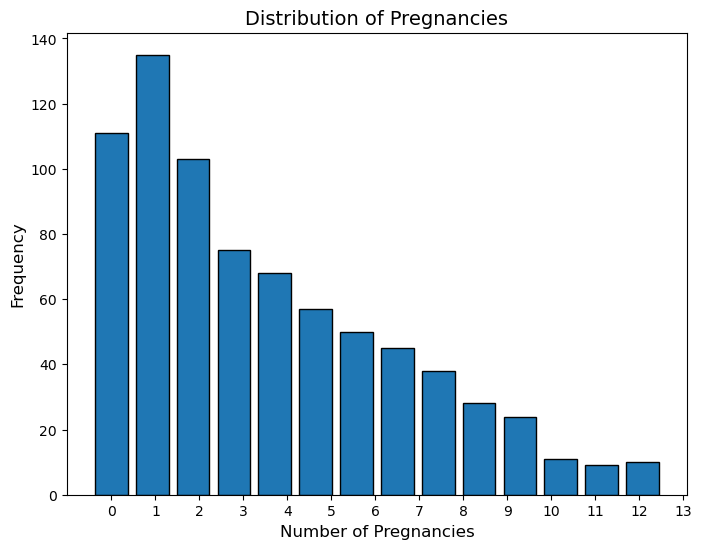

In [34]:
df = pd.read_csv("diabetes_skinthickness_zeros_median.csv")

# Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the distribution of 'Pregnancies'.
# The number of bins is set to the maximum value + 1 to ensure each integer count 
# (from 0 up to max) gets its own bin.
max_pregnancies = df['Pregnancies'].max()
bins = max_pregnancies + 1

df['Pregnancies'].hist(
    ax=ax, 
    bins=bins, 
    align='left', 
    rwidth=0.8, 
    edgecolor='black', 
    grid=False
)

# Set the title and labels
ax.set_title('Distribution of Pregnancies', fontsize=14)
ax.set_xlabel('Number of Pregnancies', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Set x-ticks to align with the integer values for clarity
ax.set_xticks(range(int(bins)))
ax.set_xticklabels(range(int(bins)))

# Display the plot
plt.show()

##### (2) Glucose

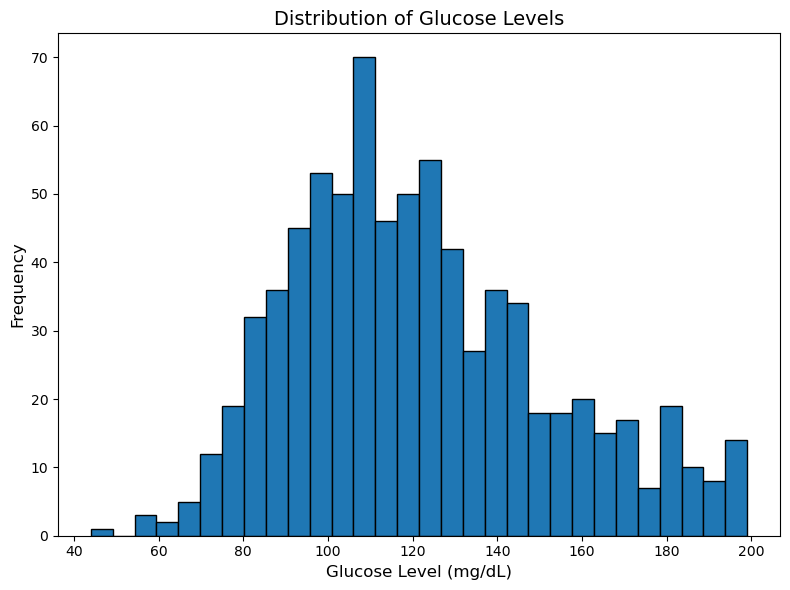

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the distribution of 'Glucose'. 
# Glucose is a continuous variable, and 30 bins is a good standard for visualizing its shape.
df['Glucose'].hist(
    ax=ax, 
    bins=30, 
    edgecolor='black', 
    grid=False
)

ax.set_title('Distribution of Glucose Levels', fontsize=14)
ax.set_xlabel('Glucose Level (mg/dL)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Ensure layout is tight
plt.tight_layout()

##### (3) BloodPressure

Text(0, 0.5, 'Frequency')

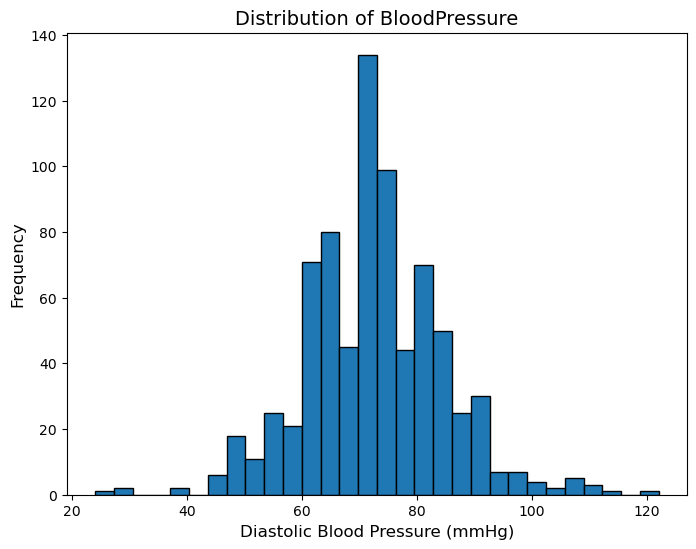

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the distribution of 'BloodPressure'. 
# Blood pressure is a continuous variable, and 30 bins is a good standard for visualizing its shape.
df['BloodPressure'].hist(
    ax=ax, 
    bins=30, 
    edgecolor='black', 
    grid=False
)

ax.set_title('Distribution of BloodPressure', fontsize=14)
ax.set_xlabel('Diastolic Blood Pressure (mmHg)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

##### (4) SkinThickness

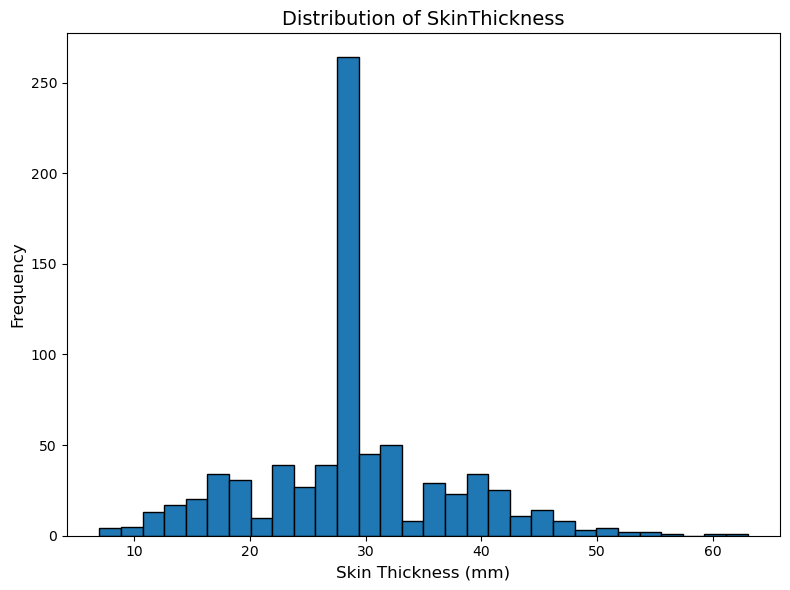

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the distribution of 'SkinThickness'. 
# Skin thickness is a continuous variable, and 30 bins is a good standard for visualizing its shape.
df['SkinThickness'].hist(
    ax=ax, 
    bins=30, 
    edgecolor='black', 
    grid=False
)

# Set the title and labels
ax.set_title('Distribution of SkinThickness', fontsize=14)
ax.set_xlabel('Skin Thickness (mm)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Ensure layout is tight
plt.tight_layout()

# Display the plot
plt.show()

##### (5) Insulin

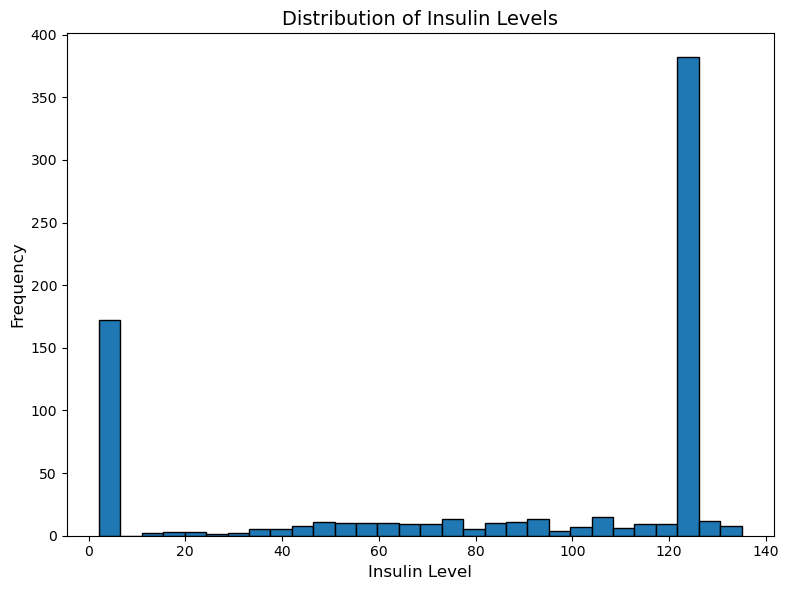

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the distribution of 'Insulin'. 
# Insulin is a continuous variable, and 30 bins is a good standard for visualizing its shape.
df['Insulin'].hist(
    ax=ax, 
    bins=30, 
    edgecolor='black', 
    grid=False
)

# Set the title and labels
ax.set_title('Distribution of Insulin Levels', fontsize=14)
ax.set_xlabel('Insulin Level', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Ensure layout is tight
plt.tight_layout()

# Display the plot
plt.show()

##### (5) BMI

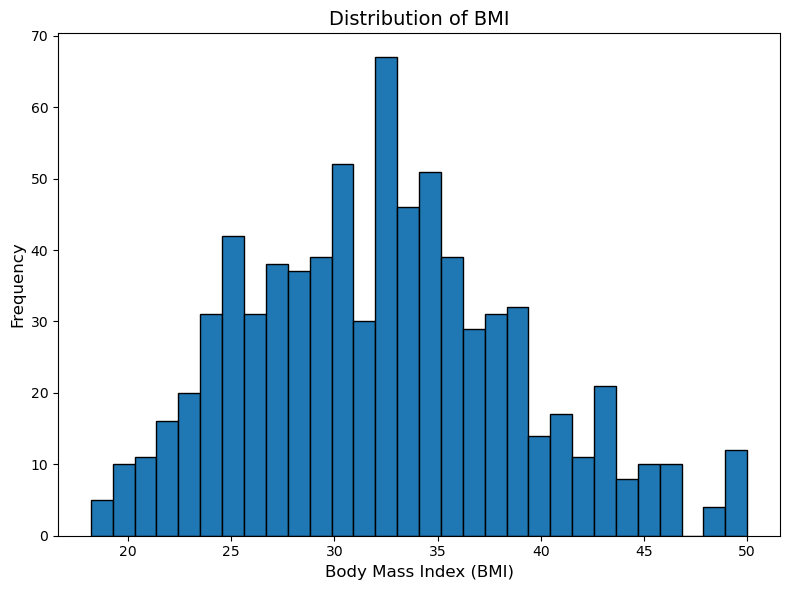

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the distribution of 'BMI'. 
# BMI is a continuous variable, and 30 bins is a good standard for visualizing its shape.
df['BMI'].hist(
    ax=ax, 
    bins=30, 
    edgecolor='black', 
    grid=False
)

# Set the title and labels
ax.set_title('Distribution of BMI', fontsize=14)
ax.set_xlabel('Body Mass Index (BMI)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Ensure layout is tight
plt.tight_layout()

# Display the plot
plt.show()

##### (6) Diabete Pedigree Function

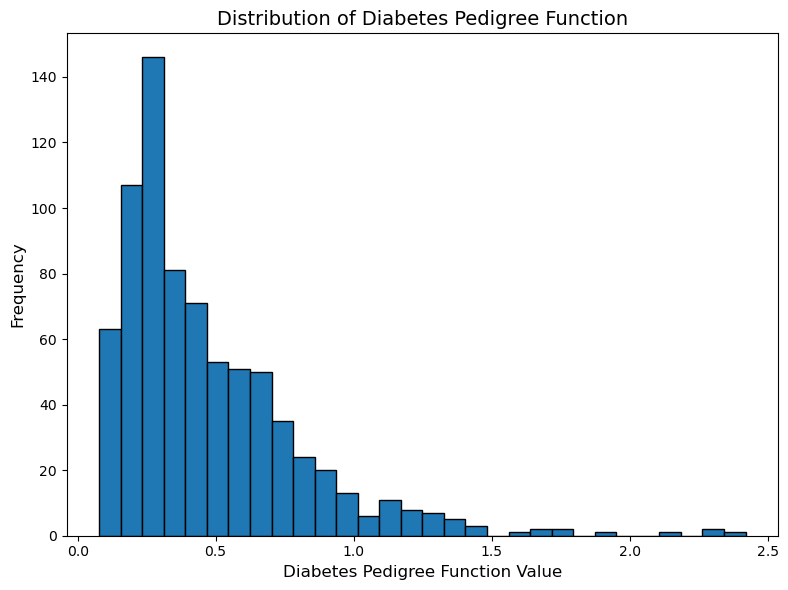

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the distribution of 'DiabetesPedigreeFunction'. 
# It is a continuous variable, and 30 bins is a good standard for visualizing its shape.
df['DiabetesPedigreeFunction'].hist(
    ax=ax, 
    bins=30, 
    edgecolor='black', 
    grid=False
)

# Set the title and labels
ax.set_title('Distribution of Diabetes Pedigree Function', fontsize=14)
ax.set_xlabel('Diabetes Pedigree Function Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Ensure layout is tight
plt.tight_layout()

# Display the plot
plt.show()

##### (7) Age

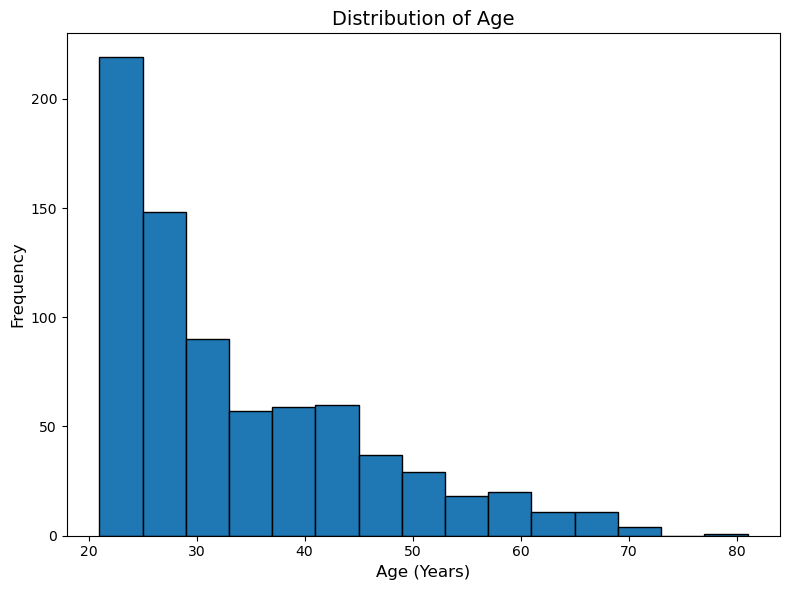

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the distribution of 'Age'. 
# Use 15 bins for good visual representation of the age data.
df['Age'].hist(
    ax=ax, 
    bins=15, 
    edgecolor='black', 
    grid=False
)

# Set the title and labels
ax.set_title('Distribution of Age', fontsize=14)
ax.set_xlabel('Age (Years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Ensure layout is tight
plt.tight_layout()

# Display the plot
plt.show()

#### Normalization

#### (1) Pregnancies - min max normalization use minimum as 0 and maximum as 1

In [48]:
column_name = 'Pregnancies'
min_val = df[column_name].min()
max_val = df[column_name].max()

# 2. Apply Min-Max Normalization
# The formula is: X_norm = (X - X_min) / (X_max - X_min)
df['Pregnancies_MinMaxScaled'] = (df[column_name] - min_val) / (max_val - min_val)

# 3. Round the scaled values to 3 decimal places
df['Pregnancies_MinMaxScaled'] = df['Pregnancies_MinMaxScaled'].round(3)

# The resulting column 'Pregnancies_MinMaxScaled' is now added to the DataFrame.
# You can view the first few rows for comparison:
print(df[[column_name, 'Pregnancies_MinMaxScaled']].head())

   Pregnancies  Pregnancies_MinMaxScaled
0            6                     0.462
1            1                     0.077
2            8                     0.615
3            1                     0.077
4            0                     0.000


#### (2) Glucose - z score normalization

In [49]:
column_name = 'Glucose'
mean_val = df[column_name].mean()
std_val = df[column_name].std()

# 2. Apply Z-Score Normalization
# The formula is: X_norm = (X - X_mean) / X_std
df['Glucose_ZScoreScaled'] = (df[column_name] - mean_val) / std_val

# 3. Round the scaled values to 3 decimal places
df['Glucose_ZScoreScaled'] = df['Glucose_ZScoreScaled'].round(3)

# The resulting column 'Glucose_ZScoreScaled' is now added to the DataFrame.
# You can view the first few rows for comparison:
print(df[[column_name, 'Glucose_ZScoreScaled']].head())

   Glucose  Glucose_ZScoreScaled
0      148                 0.870
1       85                -1.202
2      183                 2.021
3       89                -1.070
4      137                 0.508


#### (3) BloodPressure - z score normalization

In [50]:
column_name = 'BloodPressure'
mean_val = df[column_name].mean()
std_val = df[column_name].std()

# 2. Apply Z-Score Normalization
# The formula is: X_norm = (X - X_mean) / X_std
df['BloodPressure_ZScoreScaled'] = (df[column_name] - mean_val) / std_val

# 3. Round the scaled values to 3 decimal places
df['BloodPressure_ZScoreScaled'] = df['BloodPressure_ZScoreScaled'].round(3)

# The resulting column 'BloodPressure_ZScoreScaled' is now added to the DataFrame.
# You can view the first few rows for comparison:
print(df[[column_name, 'BloodPressure_ZScoreScaled']].head())

   BloodPressure  BloodPressure_ZScoreScaled
0             72                      -0.033
1             66                      -0.528
2             64                      -0.693
3             66                      -0.528
4             40                      -2.673


#### (4) SkinThickness - z score normalization

In [51]:
column_name = 'SkinThickness'
mean_val = df[column_name].mean()
std_val = df[column_name].std()

# 2. Apply Z-Score Normalization
# The formula is: X_norm = (X - X_mean) / X_std
df['SkinThickness_ZScoreScaled'] = (df[column_name] - mean_val) / std_val

# 3. Round the scaled values to 3 decimal places
df['SkinThickness_ZScoreScaled'] = df['SkinThickness_ZScoreScaled'].round(3)

# The resulting column 'SkinThickness_ZScoreScaled' is now added to the DataFrame.
# You can view the first few rows for comparison:
print(df[[column_name, 'SkinThickness_ZScoreScaled']].head())

   SkinThickness  SkinThickness_ZScoreScaled
0             35                       0.712
1             29                       0.001
2             29                       0.001
3             23                      -0.711
4             35                       0.712


#### (5) Insulin - Robust normalization

In [52]:
column_name = 'Insulin'

# 2. Calculate Median, Q1, Q3, and IQR for Robust Scaling
median_val = df[column_name].median()
q1 = df[column_name].quantile(0.25)
q3 = df[column_name].quantile(0.75)
iqr = q3 - q1

# Handle the case where IQR is 0 due to imputation
if iqr == 0:
    # Use a small epsilon to prevent ZeroDivisionError and allow scaling.
    # This is a robust way to handle the situation when IQR is 0 for non-constant data.
    epsilon = 1e-6
    denominator = iqr + epsilon
else:
    denominator = iqr

# 3. Apply Robust Normalization (Robust Scaling)
# The formula is: X_norm = (X - Median) / (IQR)
df['Insulin_RobustScaled'] = (df[column_name] - median_val) / denominator
    
# 4. Round the scaled values to 3 decimal places
df['Insulin_RobustScaled'] = df['Insulin_RobustScaled'].round(3)

# The resulting column 'Insulin_RobustScaled' is now added to the DataFrame.
# You can view the first few rows for comparison:
print(df[[column_name, 'Insulin_RobustScaled']].head())

      Insulin  Insulin_RobustScaled
0  125.000000                 0.000
1  125.000000                 0.000
2  125.000000                 0.000
3   94.000000                -0.368
4    2.225309                -1.457


#### (6) BMI - z score normalization

In [53]:
column_name = 'BMI'
mean_val = df[column_name].mean()
std_val = df[column_name].std()

# 2. Apply Z-Score Normalization
# The formula is: X_norm = (X - X_mean) / X_std
df['BMI_ZScoreScaled'] = (df[column_name] - mean_val) / std_val

# 3. Round the scaled values to 3 decimal places
df['BMI_ZScoreScaled'] = df['BMI_ZScoreScaled'].round(3)

# The resulting column 'BMI_ZScoreScaled' is now added to the DataFrame.
# You can view the first few rows for comparison:
print(df[[column_name, 'BMI_ZScoreScaled']].head())

    BMI  BMI_ZScoreScaled
0  33.6             0.185
1  26.6            -0.865
2  23.3            -1.360
3  28.1            -0.640
4  43.1             1.610


#### (7) Diabetes_Pedigree_Function - Robust normalization

In [54]:
median_val = df[column_name].median()
q1 = df[column_name].quantile(0.25)
q3 = df[column_name].quantile(0.75)
iqr = q3 - q1

# 3. Apply Robust Normalization (Robust Scaling)
# The formula is: X_norm = (X - Median) / IQR
df['DPF_RobustScaled'] = (df[column_name] - median_val) / iqr
    
# 4. Round the scaled values to 3 decimal places
df['DPF_RobustScaled'] = df['DPF_RobustScaled'].round(3)

# The resulting column 'DPF_RobustScaled' is now added to the DataFrame.
# You can view the first few rows for comparison:
print(df[[column_name, 'DPF_RobustScaled']].head())

    BMI  DPF_RobustScaled
0  33.6             0.156
1  26.6            -0.622
2  23.3            -0.989
3  28.1            -0.456
4  43.1             1.211


#### (8) Age - Robust normalization

In [55]:
column_name = 'Age'

# 2. Calculate Median, Q1, Q3, and IQR for Robust Scaling
median_val = df[column_name].median()
q1 = df[column_name].quantile(0.25)
q3 = df[column_name].quantile(0.75)
iqr = q3 - q1

# 3. Apply Robust Normalization (Robust Scaling)
# The formula is: X_norm = (X - Median) / IQR
df['Age_RobustScaled'] = (df[column_name] - median_val) / iqr
    
# 4. Round the scaled values to 3 decimal places
df['Age_RobustScaled'] = df['Age_RobustScaled'].round(3)

# The resulting column 'Age_RobustScaled' is now added to the DataFrame.
# You can view the first few rows for comparison:
print(df[[column_name, 'Age_RobustScaled']].head())

   Age  Age_RobustScaled
0   50             1.292
1   31             0.123
2   32             0.185
3   21            -0.492
4   33             0.246


### Distribution Graph after Normalization 

##### (1) Pregnancies

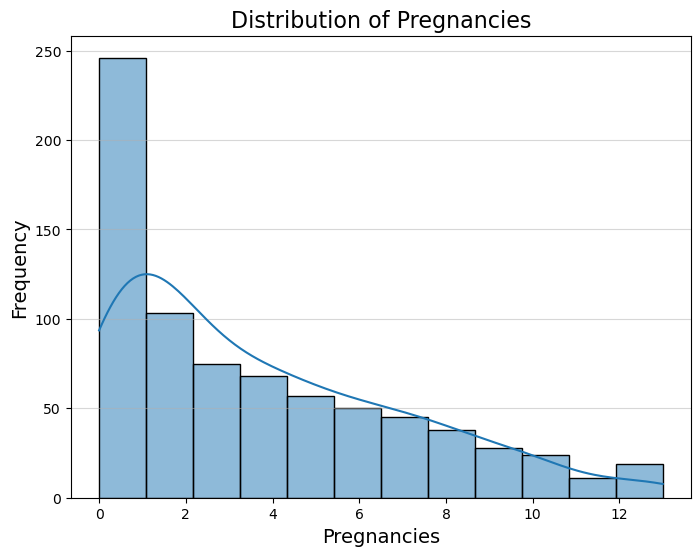

In [66]:
column = 'Pregnancies'
# 2. Change the index [0] for a different color (0 to 7 for the 8 features)
palette = sns.color_palette("tab10", n_colors=8)
plot_color = palette[0]
# ---------------------------------------------

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the distribution (Histogram with KDE)
sns.histplot(df[column], kde=True, color=plot_color)

# Set title and labels
plt.title(f'Distribution of {column}', fontsize=16)
plt.xlabel(column, fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.5)

# Save the figure
plot_filename = f'distribution_{column}.png'
plt.savefig(plot_filename)

##### (2) Glucose

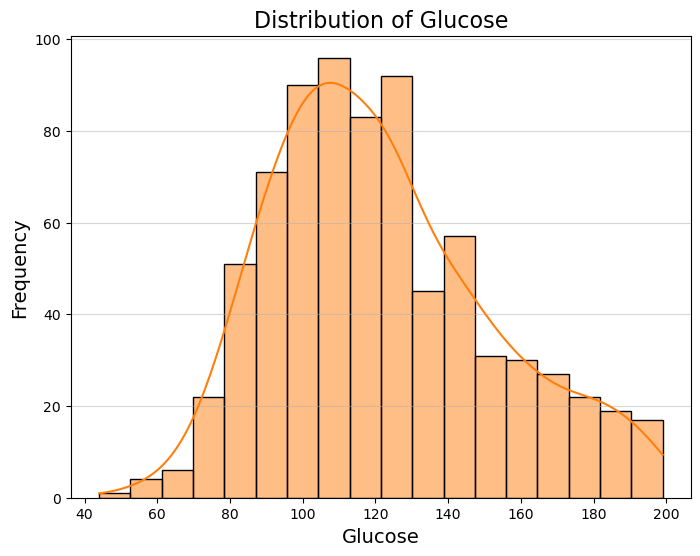

In [67]:
column = 'Glucose'

# Define the color palette and select the color for this plot
# Index [1] corresponds to the second color in the seaborn 'tab10' palette
palette = sns.color_palette("tab10", n_colors=8)
plot_color = palette[1]

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the distribution (Histogram with KDE)
sns.histplot(df[column], kde=True, color=plot_color)

# Set title and labels
plt.title(f'Distribution of {column}', fontsize=16)
plt.xlabel(column, fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.5)

# Save the figure
plot_filename = f'distribution_{column}.png'
plt.savefig(plot_filename)

##### (3) BloodPressure

Code for 'BloodPressure' distribution graph complete. The plot would be saved as 'distribution_BloodPressure.png'.


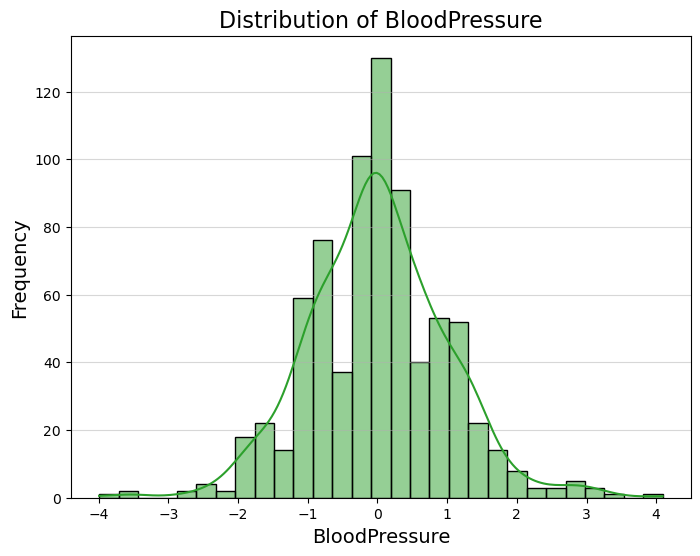

In [68]:
column = 'BloodPressure'

# Define the color palette and select the color for this plot
# Index [2] corresponds to the third color in the seaborn 'tab10' palette
palette = sns.color_palette("tab10", n_colors=8)
plot_color = palette[2]

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the distribution (Histogram with KDE)
sns.histplot(df[column], kde=True, color=plot_color)

# Set title and labels
plt.title(f'Distribution of {column}', fontsize=16)
plt.xlabel(column, fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.5)

# Save the figure
plot_filename = f'distribution_{column}.png'
plt.savefig(plot_filename)

# Note: In a live environment, the plot would be saved as 'distribution_BloodPressure.png'.
print(f"Code for '{column}' distribution graph complete. The plot would be saved as '{plot_filename}'.")

##### (4) SkinThickness

Code for 'SkinThickness' distribution graph complete. The plot would be saved as 'distribution_SkinThickness.png'.


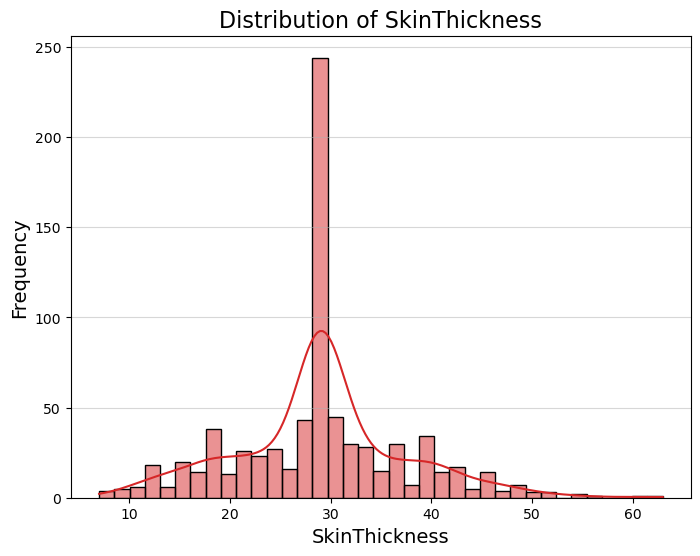

In [69]:
column = 'SkinThickness'

# Define the color palette and select the color for this plot
# Index [3] corresponds to the fourth color in the seaborn 'tab10' palette
palette = sns.color_palette("tab10", n_colors=8)
plot_color = palette[3]

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the distribution (Histogram with KDE)
sns.histplot(df[column], kde=True, color=plot_color)

# Set title and labels
plt.title(f'Distribution of {column}', fontsize=16)
plt.xlabel(column, fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.5)

# Save the figure
plot_filename = f'distribution_{column}.png'
plt.savefig(plot_filename)


# Note: In a live environment, the plot would be saved as 'distribution_SkinThickness.png'.
print(f"Code for '{column}' distribution graph complete. The plot would be saved as '{plot_filename}'.")

##### (5) Insulin

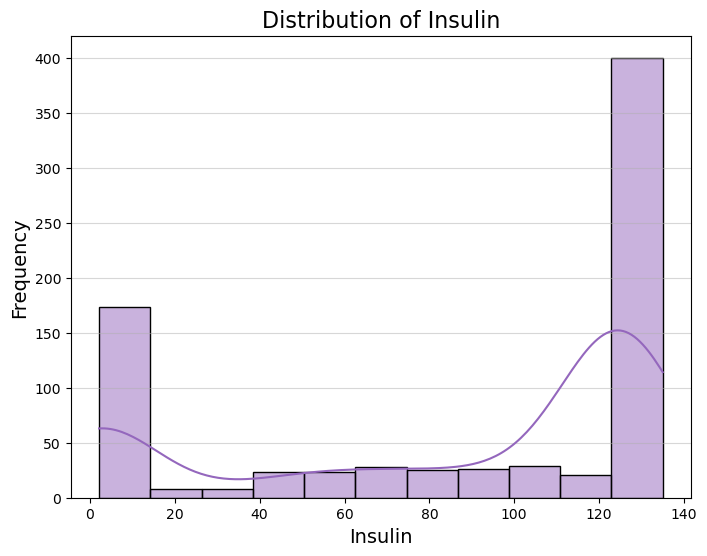

In [71]:
column = 'Insulin'

# Define the color palette and select the color for this plot
# Index [4] corresponds to the fifth color in the seaborn 'tab10' palette
palette = sns.color_palette("tab10", n_colors=8)
plot_color = palette[4]

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the distribution (Histogram with KDE)
sns.histplot(df[column], kde=True, color=plot_color)

# Set title and labels
plt.title(f'Distribution of {column}', fontsize=16)
plt.xlabel(column, fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.5)

# Save the figure
plot_filename = f'distribution_{column}.png'
plt.savefig(plot_filename)



##### (6) BMI

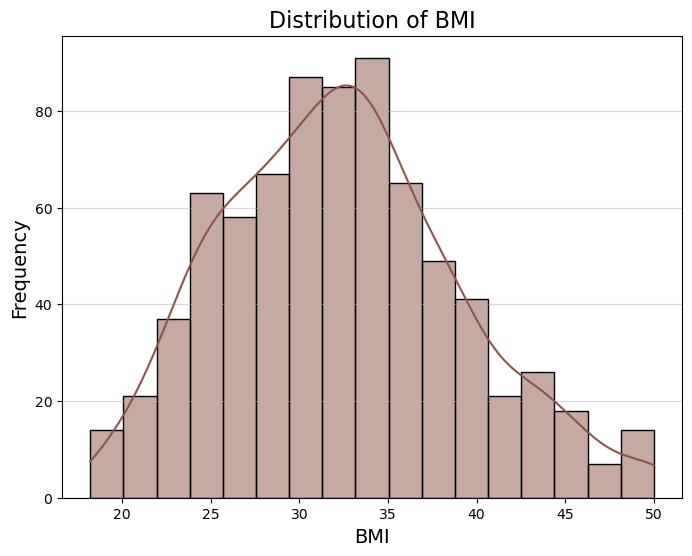

In [73]:
column = 'BMI'

# Define the color palette and select the color for this plot
# Index [5] corresponds to the sixth color in the seaborn 'tab10' palette
palette = sns.color_palette("tab10", n_colors=8)
plot_color = palette[5]

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the distribution (Histogram with KDE)
sns.histplot(df[column], kde=True, color=plot_color)

# Set title and labels
plt.title(f'Distribution of {column}', fontsize=16)
plt.xlabel(column, fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.5)

# Save the figure
plot_filename = f'distribution_{column}.png'
plt.savefig(plot_filename)

##### (7) Diabetes-Pedigree-Function

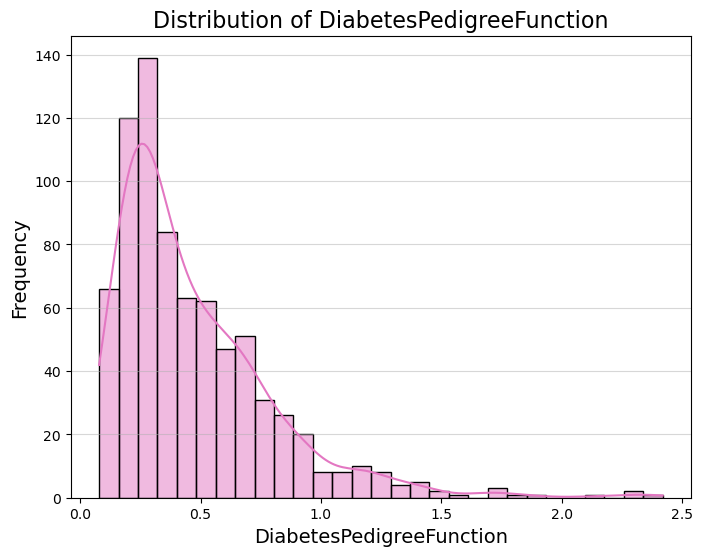

In [74]:
column = 'DiabetesPedigreeFunction'

# Define the color palette and select the color for this plot
# Index [6] corresponds to the seventh color in the seaborn 'tab10' palette
palette = sns.color_palette("tab10", n_colors=8)
plot_color = palette[6]

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the distribution (Histogram with KDE)
sns.histplot(df[column], kde=True, color=plot_color)

# Set title and labels
plt.title(f'Distribution of {column}', fontsize=16)
plt.xlabel(column, fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.5)

# Save the figure
plot_filename = f'distribution_{column}.png'
plt.savefig(plot_filename)

#### (7) Age